In [4]:
import pandas as pd
df=pd.read_csv("E:/Luminar/Machine Learning/World_cup_prediction_model/International football results/results.csv")


In [5]:
df[df['tournament']=='FIFA World Cup']

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
1490,1930-07-13,Belgium,United States,0.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
1491,1930-07-13,France,Mexico,4.0,1.0,FIFA World Cup,Montevideo,Uruguay,True
1492,1930-07-14,Brazil,Yugoslavia,1.0,2.0,FIFA World Cup,Montevideo,Uruguay,True
1493,1930-07-14,Peru,Romania,1.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
1494,1930-07-15,Argentina,France,1.0,0.0,FIFA World Cup,Montevideo,Uruguay,True
...,...,...,...,...,...,...,...,...,...
49472,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49473,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49474,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49475,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


In [6]:
df["date"].min(),df["date"].max()
# df.isna().sum()

('1872-11-30', '2026-06-27')

In [7]:
df[df["home_score"].isna()]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49409,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True
49410,2026-06-13,Brazil,Morocco,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
49411,2026-06-13,Haiti,Scotland,NaN,NaN,FIFA World Cup,Foxborough,United States,True
49412,2026-06-13,Australia,Turkey,NaN,NaN,FIFA World Cup,Vancouver,Canada,True
49413,2026-06-14,Germany,Curaçao,NaN,NaN,FIFA World Cup,Houston,United States,True
...,...,...,...,...,...,...,...,...,...
49472,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49473,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49474,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49475,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


In [8]:
def get_result(row):
    if row['home_score']>row['away_score']:
        return "H"#home
    elif row['home_score']<row['away_score']:
        return "A"#away
    else:
        return "D"#draw
df['result'] = df.apply(get_result, axis=1)
df['result'].value_counts()
# df.iloc[1655:1700]

result
H    24215
A    13960
D    11302
Name: count, dtype: int64

In [9]:
df['country'].nunique()

269

In [10]:
df["goal_difference"]=df["home_score"]-df["away_score"]
df["date"].dtype
df['date']=pd.to_datetime(df['date'])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

In [11]:
historical_df=df[df['home_score'].notna()].copy()
upcoming_df=df[df['home_score'].isna()].copy()

historical_df=historical_df[historical_df['date']>='2000-01-01']

In [12]:
print("Historical matches:", historical_df.shape)
print("Upcoming WC matches:", upcoming_df.shape)

Historical matches: (25347, 13)
Upcoming WC matches: (68, 13)


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

india=df[((df['home_team']=='India')|(df['away_team']=='India') & (df['home_score'].notna()))].copy()
def india_result(row):
    if row['home_team']=='India':
        if row['home_score']>row['away_score']:
            return "Win"
        elif row['home_score']<row['away_score']:
            return "Loss"
        else: return "Draw"
    else:
        if row['away_score']>row['home_score']:
            return "Win"
        elif row['away_score']<row['home_score']:
            return "Loss"
        else: return "Draw"

india["India_result"]=india.apply(india_result,axis=1)
print("Total India Matches:",len(india))
print(india['India_result'].value_counts())


Total India Matches: 534
India_result
Loss    224
Win     190
Draw    120
Name: count, dtype: int64


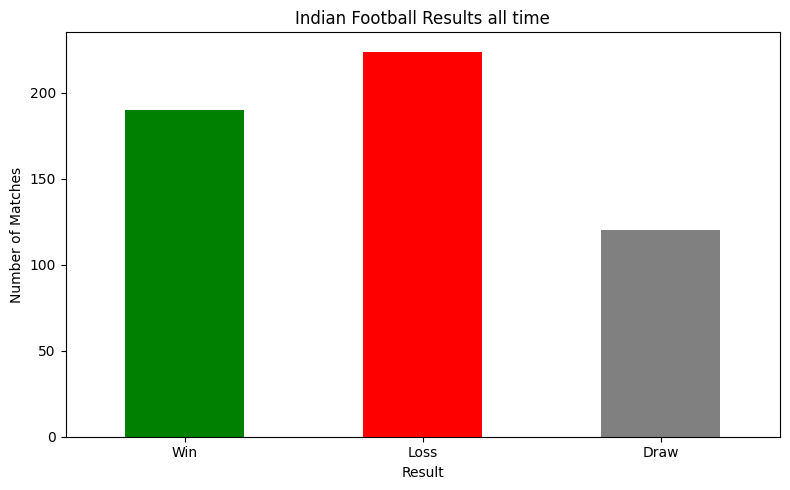

In [14]:
plt.figure(figsize=(8,5))
counts = india['India_result'].value_counts()
counts = counts.reindex(['Win', 'Loss', 'Draw'])
colors=['green','red','gray']
counts.plot(kind='bar',color=colors)
plt.title("Indian Football Results all time")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

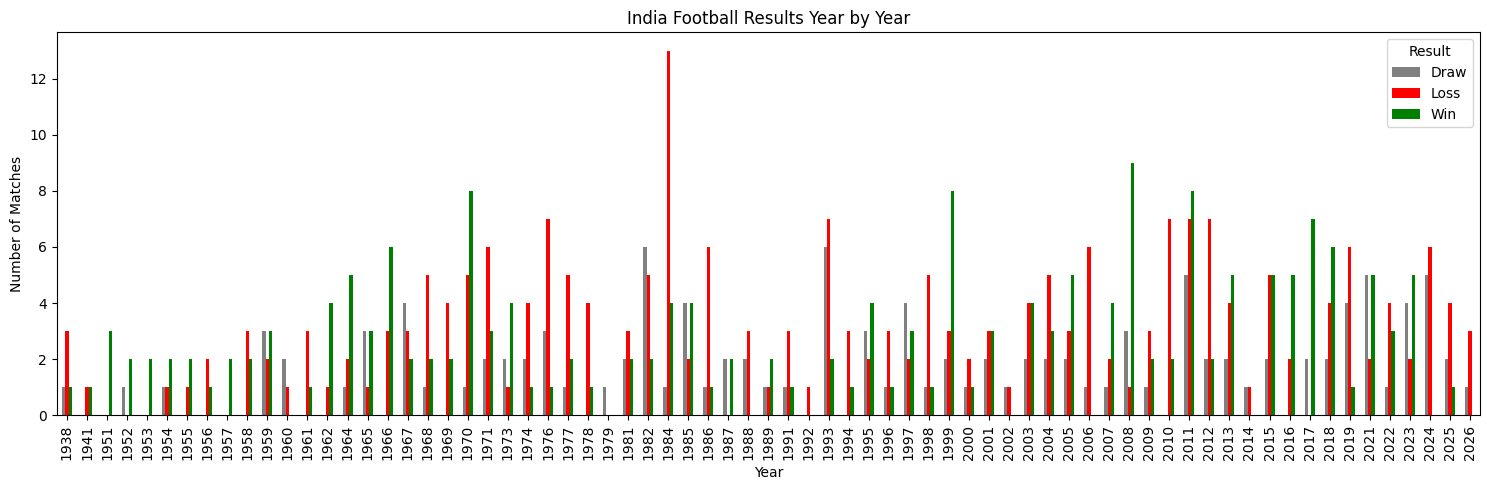

In [15]:

india['year'] = india['date'].dt.year

yearly = india.groupby(['year', 'India_result']).size().unstack(fill_value=0)
yearly.plot(kind='bar', figsize=(15, 5), color=['gray', 'red', 'green'])

plt.title("India Football Results Year by Year")
plt.xlabel("Year")
plt.ylabel("Number of Matches")
plt.legend(title="Result")
plt.tight_layout()
plt.show()

In [16]:
print(historical_df.shape)
print(upcoming_df.shape)

(25347, 13)
(68, 13)


In [17]:
historical_df=historical_df.sort_values("date").reset_index(drop=True)
historical_df.index

RangeIndex(start=0, stop=25347, step=1)

In [18]:
def get_team_form(team,date,df,n=10):
    past=df[(((df['home_team']==team) | (df['away_team']==team)))&(df['date']<date)].tail(n)
    if len(past)==0:
        return 0,0,0
    goal_scored=[]
    goal_conceded=[]
    wins=[]
    for _,row in past.iterrows():
        if row['home_team']==team:
            goal_scored.append(row['home_score'])
            goal_conceded.append(row['away_score'])
            wins.append(1 if row['result']=='H' else 0)
        else:
            goal_scored.append(row['away_score'])
            goal_conceded.append(row['home_score'])
            wins.append(1 if row['result']=='A' else 0)
    return round(sum(goal_scored)/len(goal_scored),2),\
           round(sum(goal_conceded)/len(goal_conceded),2),\
           round(sum(wins)/len(wins),2) 

In [19]:
avg_goal_scored,avg_goal_concided,win_rate=get_team_form(team="Brazil",date=pd.Timestamp('2026-04-01'),df=historical_df)
print("Average_Goal_Scored:",avg_goal_scored)
print("Average_Goal_Conceded:",avg_goal_concided)
print("Win Rate:",win_rate)


Average_Goal_Scored: 1.8
Average_Goal_Conceded: 0.8
Win Rate: 0.5


In [20]:
home_scored=[]
home_conceded=[]
home_win_rate=[]
away_scored=[]
away_conceded=[]
away_win_rate=[]

for idx,row in historical_df.iterrows():# idx catches the index number but we don't use it, only row matters
    hs,hc,hw=get_team_form(row["home_team"],row['date'],historical_df)
    as_,ac,aw=get_team_form(row["away_team"],row['date'],historical_df)
    home_scored.append(hs)
    home_conceded.append(hc)
    home_win_rate.append(hw)
    away_scored.append(as_)
    away_conceded.append(ac)
    away_win_rate.append(aw)

historical_df['home_scored']=home_scored
historical_df['home_conceded']=home_conceded
historical_df['home_win_rate']=home_win_rate
historical_df['away_scored']=away_scored
historical_df['away_conceded']=away_conceded
historical_df['away_win_rate']=away_win_rate










In [21]:
historical_df['neutral'] = historical_df['neutral'].astype(int)
historical_df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,goal_difference,year,month,home_scored,home_conceded,home_win_rate,away_scored,away_conceded,away_win_rate
0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,Aswan,Egypt,0,H,1.0,2000,1,0.0,0.0,0.0,0.0,0.0,0.0
1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,Tunis,Tunisia,0,H,7.0,2000,1,0.0,0.0,0.0,1.0,2.0,0.0
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,Port of Spain,Trinidad and Tobago,0,D,0.0,2000,1,0.0,0.0,0.0,0.0,0.0,0.0
3,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,Ouagadougou,Burkina Faso,0,D,0.0,2000,1,0.0,0.0,0.0,0.0,0.0,0.0
4,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,Los Angeles,United States,1,D,0.0,2000,1,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
features=['home_scored','home_conceded','home_win_rate','away_scored','away_conceded','away_win_rate','neutral']
X=historical_df[features]
y=historical_df["result"]
print(X.shape)
print(y.shape)
historical_df = historical_df.drop(columns=['city', 'country', 'year', 'month'])
y.value_counts()

(25347, 7)
(25347,)


result
H    12205
A     7238
D     5904
Name: count, dtype: int64

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape[0])
print(X_test.shape[0])

20277
5070


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

models={"Logistic Regression":LogisticRegression(max_iter=1000),
"Naive Bayes":GaussianNB(),
"KNN":KNeighborsClassifier(),
"Random Forest":RandomForestClassifier(n_estimators=99)
}

for name,model in models.items():
    model.fit(X_train,y_train)
    score=model.score(X_test,y_test)
    print(f"{name}:{round(score*100,2)}%")

Logistic Regression:54.1%
Naive Bayes:51.22%
KNN:45.27%
Random Forest:50.34%


In [25]:
lr_model=LogisticRegression(max_iter=1000)
lr_model.fit(X_train,y_train)
lr_model.score(X_test,y_test)*100

54.1025641025641

In [26]:
#Add more features
tournament_weight = {
    'Friendly': 1,
    'FIFA World Cup qualification': 3,
    'UEFA Euro qualification': 3,
    'Africa Cup of Nations qualification': 3,
    'Copa América': 4,
    'UEFA Euro': 4,
    'Africa Cup of Nations': 4,
    'FIFA World Cup': 5
}
historical_df["tournament_weight"]=historical_df['tournament'].map(tournament_weight).fillna(2)
historical_df["tournament_weight"].value_counts()
historical_df

,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,home_scored,home_conceded,home_win_rate,away_scored,away_conceded,away_win_rate,tournament_weight
0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,0,H,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,0,H,7.0,0.0,0.0,0.0,1.0,2.0,0.0,1.0
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,0,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,0,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,1,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25342,2026-06-10,Afghanistan,Pakistan,0.0,2.0,Diamond Jubilee International Football Tournament,1,A,-2.0,0.4,1.4,0.1,0.6,2.2,0.2,2.0
25343,2026-06-11,Mexico,South Africa,2.0,0.0,FIFA World Cup,0,H,2.0,1.6,0.4,0.6,1.5,1.0,0.5,5.0
25344,2026-06-11,South Korea,Czech Republic,2.0,1.0,FIFA World Cup,1,H,1.0,1.5,1.2,0.6,2.2,0.9,0.5,5.0
25345,2026-06-12,Canada,Bosnia and Herzegovina,1.0,1.0,FIFA World Cup,0,D,0.0,1.1,0.4,0.4,2.0,1.0,0.3,5.0


In [27]:
#Build Head To Head
def get_h2h(home_team, away_team, date, df):
    c1 = (df['home_team']==home_team) & (df['away_team']==away_team)
    c2 = (df['home_team']==away_team) & (df['away_team']==home_team)
    past = df[(c1 | c2) & (df['date'] < date)]
    
    if len(past)==0:
        return 0, 0, 0
    home_wins=0
    away_wins=0
    draws=0
    for _,row in past.iterrows():
        if row['result']=="D":
            draws+=1
        elif row["result"]=="H":
            if row["home_team"]==home_team:
                home_wins+=1
            else:
                away_wins+=1
        elif row["result"]=="A":
            if row["away_team"]==home_team:
                home_wins+=1
            else:
                away_wins+=1
    

    
    return home_wins, away_wins, draws


In [28]:
brazil,argentina,draw=get_h2h(home_team="England",away_team="Argentina",date=pd.Timestamp('2026-04-01'),df=historical_df)
print("Brazil Won:",brazil)
print("Argentina Won:",argentina)
print("Draws:",draw)


Brazil Won: 2
Argentina Won: 0
Draws: 1


In [29]:
# # Drop old buggy columns
# historical_df = historical_df.drop(columns=['h2h_home_wins', 'h2h_away_wins', 'h2h_draws'])

# Rerun loop with fixed function
h2h_home_wins = []
h2h_away_wins = []
h2h_draws = []

for idx, row in historical_df.iterrows():
    hw, aw, d = get_h2h(row['home_team'], row['away_team'], row['date'], historical_df)
    h2h_home_wins.append(hw)
    h2h_away_wins.append(aw)
    h2h_draws.append(d)

historical_df['h2h_home_wins'] = h2h_home_wins
historical_df['h2h_away_wins'] = h2h_away_wins
historical_df['h2h_draws'] = h2h_draws

historical_df.tail()

,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,home_scored,home_conceded,home_win_rate,away_scored,away_conceded,away_win_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws
25342,2026-06-10,Afghanistan,Pakistan,0.0,2.0,Diamond Jubilee International Football Tournament,1,A,-2.0,0.4,1.4,0.1,0.6,2.2,0.2,2.0,1,4,2
25343,2026-06-11,Mexico,South Africa,2.0,0.0,FIFA World Cup,0,H,2.0,1.6,0.4,0.6,1.5,1.0,0.5,5.0,1,1,1
25344,2026-06-11,South Korea,Czech Republic,2.0,1.0,FIFA World Cup,1,H,1.0,1.5,1.2,0.6,2.2,0.9,0.5,5.0,1,1,0
25345,2026-06-12,Canada,Bosnia and Herzegovina,1.0,1.0,FIFA World Cup,0,D,0.0,1.1,0.4,0.4,2.0,1.0,0.3,5.0,0,0,0
25346,2026-06-12,United States,Paraguay,4.0,1.0,FIFA World Cup,0,H,3.0,1.8,1.7,0.5,1.2,1.0,0.4,5.0,4,2,0


In [30]:
historical_df.tail()


,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,home_scored,home_conceded,home_win_rate,away_scored,away_conceded,away_win_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws
25342,2026-06-10,Afghanistan,Pakistan,0.0,2.0,Diamond Jubilee International Football Tournament,1,A,-2.0,0.4,1.4,0.1,0.6,2.2,0.2,2.0,1,4,2
25343,2026-06-11,Mexico,South Africa,2.0,0.0,FIFA World Cup,0,H,2.0,1.6,0.4,0.6,1.5,1.0,0.5,5.0,1,1,1
25344,2026-06-11,South Korea,Czech Republic,2.0,1.0,FIFA World Cup,1,H,1.0,1.5,1.2,0.6,2.2,0.9,0.5,5.0,1,1,0
25345,2026-06-12,Canada,Bosnia and Herzegovina,1.0,1.0,FIFA World Cup,0,D,0.0,1.1,0.4,0.4,2.0,1.0,0.3,5.0,0,0,0
25346,2026-06-12,United States,Paraguay,4.0,1.0,FIFA World Cup,0,H,3.0,1.8,1.7,0.5,1.2,1.0,0.4,5.0,4,2,0


In [31]:
historical_df.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,home_scored,home_conceded,home_win_rate,away_scored,away_conceded,away_win_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws
0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,0,H,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0
1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,0,H,7.0,0.0,0.0,0.0,1.0,2.0,0.0,1.0,0,0,0
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,0,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0
3,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,0,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0
4,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,1,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0


In [32]:
from sklearn.tree import DecisionTreeClassifier

features = [
    'home_scored', 'home_conceded', 'home_win_rate',
    'away_scored', 'away_conceded', 'away_win_rate',
    'neutral', 'tournament_weight',
    'h2h_home_wins', 'h2h_away_wins', 'h2h_draws'
]

X = historical_df[features]
y = historical_df['result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LogisticRegression(max_iter=1000)
nb_model = GaussianNB()
knn_model = KNeighborsClassifier(n_neighbors=5)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)

models = {
    'Logistic Regression': lr_model,
    'Naive Bayes': nb_model,
    'KNN': knn_model,
    'Random Forest': rf_model,
    'Decision Tree': dt_model
}

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"{name}: {round(score*100, 2)}%")

Logistic Regression: 55.86%
Naive Bayes: 53.16%
KNN: 47.71%
Random Forest: 54.08%
Decision Tree: 43.77%


In [33]:
def calculate_elo(df,k=32,initial=1000):
    elo={}
    elo_home=[]
    elo_away=[]
    for _,row in df.iterrows():
        home=row["home_team"]
        away= row["away_team"]

        #get current ratings defaukt 1000 if new team #get() gives key and default value
        home_elo=elo.get(home,initial)
        away_elo=elo.get(away,initial)
        #store ratings  before match
        elo_home.append(home_elo)
        elo_away.append(away_elo)

        #expected win probability
        expected_home=1/(1+10**((away_elo-home_elo)/400))
        expected_away=1-expected_home

        #Actuall Result
        if row['result']=='H':
            actual_home,actual_away=1,0
        elif row['result']=="A":
            actual_home,actual_away=0,1
        else:
            actual_home,actual_away=0.5,0.5
        
        #update rating
        elo[home]=home_elo+k*(actual_home-expected_home)
        elo[away]=away_elo+k*(actual_away-expected_away)

    df['elo_home'] = elo_home
    df['elo_away'] = elo_away
    return df, elo





In [34]:
historical_df,final_elo=calculate_elo(historical_df)
historical_df['elo_diff'] = historical_df['elo_home'] - historical_df['elo_away']
print(f"\nTop 10 teams by Elo rating:")
sorted_elo=sorted(final_elo.items(),key=lambda x:x[1],reverse=True)
for team,rating in sorted_elo[:10]:
    print(f"{team}:{round(rating)}")


Top 10 teams by Elo rating:
Argentina:1520
Spain:1511
France:1451
Brazil:1422
Portugal:1420
England:1409
Germany:1408
Colombia:1405
Morocco:1405
Japan:1401


In [35]:
historical_df

,date,home_team,away_team,home_score,away_score,tournament,neutral,result,goal_difference,home_scored,...,away_scored,away_conceded,away_win_rate,tournament_weight,h2h_home_wins,h2h_away_wins,h2h_draws,elo_home,elo_away,elo_diff
0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,0,H,1.0,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1000.000000,1000.000000,0.000000
1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,0,H,7.0,0.0,...,1.0,2.0,0.0,1.0,0,0,0,1000.000000,984.000000,16.000000
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,0,D,0.0,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1000.000000,1000.000000,0.000000
3,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,0,D,0.0,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1000.000000,1000.000000,0.000000
4,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,1,D,0.0,0.0,...,0.0,0.0,0.0,1.0,0,0,0,1000.000000,1000.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25342,2026-06-10,Afghanistan,Pakistan,0.0,2.0,Diamond Jubilee International Football Tournament,1,A,-2.0,0.4,...,0.6,2.2,0.2,2.0,1,4,2,767.676488,689.148617,78.527871
25343,2026-06-11,Mexico,South Africa,2.0,0.0,FIFA World Cup,0,H,2.0,1.6,...,1.5,1.0,0.5,5.0,1,1,1,1360.640583,1140.254457,220.386126
25344,2026-06-11,South Korea,Czech Republic,2.0,1.0,FIFA World Cup,1,H,1.0,1.5,...,2.2,0.9,0.5,5.0,1,1,0,1314.211673,1231.850593,82.361080
25345,2026-06-12,Canada,Bosnia and Herzegovina,1.0,1.0,FIFA World Cup,0,D,0.0,1.1,...,2.0,1.0,0.3,5.0,0,0,0,1301.659888,1088.057463,213.602425


In [36]:
features = [
    'home_scored', 'home_conceded', 'home_win_rate',
    'away_scored', 'away_conceded', 'away_win_rate',
    'neutral', 'tournament_weight',
    'h2h_home_wins', 'h2h_away_wins', 'h2h_draws',
    'elo_home', 'elo_away','elo_diff'
]

X = historical_df[features]
y = historical_df['result']
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# lr_model.fit(X_train_scaled, y_train)
# for name, model in models.items():
#     model.fit(X_train, y_train)
#     score = model.score(X_test, y_test)
#     print(f"{name}: {round(score*100, 2)}%")

In [37]:


lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train_scaled, y_train)
print(f"Logistic Regression scaled: {round(lr_model.score(X_test_scaled, y_test)*100, 2)}%")

Logistic Regression scaled: 57.3%


In [38]:
home_scored=[]
home_conceded=[]
home_win_rate=[]
away_scored=[]
away_conceded=[]
away_win_rate=[]
h2h_home_wins=[]
h2h_away_wins=[]
h2h_draws=[]

for idx, row in upcoming_df.iterrows():
    hs,hc,hw = get_team_form(row['home_team'], row['date'], historical_df)
    as_,ac,aw = get_team_form(row['away_team'], row['date'], historical_df)
    h2hw, h2haw, h2hd = get_h2h(row['home_team'], row['away_team'], row['date'], historical_df)
    
    home_scored.append(hs)
    home_conceded.append(hc)
    home_win_rate.append(hw)
    away_scored.append(as_)
    away_conceded.append(ac)
    away_win_rate.append(aw)
    h2h_home_wins.append(h2hw)
    h2h_away_wins.append(h2haw)
    h2h_draws.append(h2hd)

upcoming_df['home_scored'] = home_scored
upcoming_df['home_conceded'] = home_conceded
upcoming_df['home_win_rate'] = home_win_rate
upcoming_df['away_scored'] = away_scored
upcoming_df['away_conceded'] = away_conceded
upcoming_df['away_win_rate'] = away_win_rate
upcoming_df['h2h_home_wins'] = h2h_home_wins
upcoming_df['h2h_away_wins'] = h2h_away_wins
upcoming_df['h2h_draws'] = h2h_draws
upcoming_df['neutral'] = upcoming_df['neutral'].astype(int)
upcoming_df['tournament_weight'] = upcoming_df['tournament'].map(tournament_weight).fillna(2)
upcoming_df['elo_home'] = upcoming_df['home_team'].map(final_elo).fillna(1000)
upcoming_df['elo_away'] = upcoming_df['away_team'].map(final_elo).fillna(1000)
upcoming_df['elo_diff'] = upcoming_df['elo_home'] - upcoming_df['elo_away']


In [39]:
X_upcoming = upcoming_df[features]
X_upcoming_scaled = scaler.transform(X_upcoming)
predictions = lr_model.predict(X_upcoming_scaled)

upcoming_df['predicted_result'] = predictions

for _, row in upcoming_df.iterrows():
    home = row['home_team']
    away = row['away_team']
    pred = row['predicted_result']
    
    if pred == 'H':
        outcome = f"{home} wins"
    elif pred == 'A':
        outcome = f"{away} wins"
    else:
        outcome = "Draw"
    
    print(f"{home} vs {away}: {outcome}")

Qatar vs Switzerland: Switzerland wins
Brazil vs Morocco: Morocco wins
Haiti vs Scotland: Scotland wins
Australia vs Turkey: Turkey wins
Germany vs Curaçao: Germany wins
Ivory Coast vs Ecuador: Ecuador wins
Netherlands vs Japan: Japan wins
Sweden vs Tunisia: Sweden wins
Belgium vs Egypt: Belgium wins
Iran vs New Zealand: Iran wins
Spain vs Cape Verde: Spain wins
Saudi Arabia vs Uruguay: Uruguay wins
France vs Senegal: France wins
Iraq vs Norway: Norway wins
Argentina vs Algeria: Argentina wins
Austria vs Jordan: Austria wins
Portugal vs DR Congo: Portugal wins
Uzbekistan vs Colombia: Colombia wins
England vs Croatia: England wins
Ghana vs Panama: Panama wins
Czech Republic vs South Africa: Czech Republic wins
Mexico vs South Korea: Mexico wins
Switzerland vs Bosnia and Herzegovina: Switzerland wins
Canada vs Qatar: Canada wins
Scotland vs Morocco: Morocco wins
Brazil vs Haiti: Brazil wins
United States vs Australia: United States wins
Turkey vs Paraguay: Turkey wins
Germany vs Ivory Co

In [40]:
print(historical_df.columns.tolist())

['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'neutral', 'result', 'goal_difference', 'home_scored', 'home_conceded', 'home_win_rate', 'away_scored', 'away_conceded', 'away_win_rate', 'tournament_weight', 'h2h_home_wins', 'h2h_away_wins', 'h2h_draws', 'elo_home', 'elo_away', 'elo_diff']


In [41]:
from sklearn.metrics import classification_report

y_pred = lr_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       0.53      0.53      0.53      1438
           D       0.35      0.02      0.04      1176
           H       0.60      0.86      0.70      2456

    accuracy                           0.57      5070
   macro avg       0.49      0.47      0.43      5070
weighted avg       0.52      0.57      0.50      5070



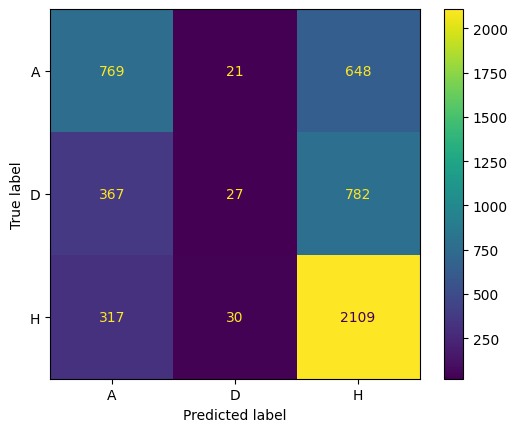

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [43]:
probs = lr_model.predict_proba(X_test_scaled)

print(lr_model.classes_)
print(probs[:10])

['A' 'D' 'H']
[[0.74959492 0.18242703 0.06797805]
 [0.09578586 0.14297973 0.76123442]
 [0.16486406 0.34577838 0.48935757]
 [0.02438286 0.05542162 0.92019551]
 [0.05645559 0.14250542 0.80103899]
 [0.09538589 0.24431583 0.66029828]
 [0.25263563 0.26229808 0.48506629]
 [0.14973568 0.28593394 0.56433039]
 [0.21260653 0.28683807 0.5005554 ]
 [0.19106154 0.22950107 0.57943739]]


In [44]:
print(X_upcoming.shape)
print(scaler.feature_names_in_)


(68, 14)
['home_scored' 'home_conceded' 'home_win_rate' 'away_scored'
 'away_conceded' 'away_win_rate' 'neutral' 'tournament_weight'
 'h2h_home_wins' 'h2h_away_wins' 'h2h_draws' 'elo_home' 'elo_away'
 'elo_diff']


In [49]:
probabilities= lr_model.predict_proba(X_upcoming_scaled)
upcoming_df = upcoming_df.reset_index(drop=True)
for i,row in upcoming_df.iterrows():
    away_prob=probabilities[i][0]*100
    draw_prob=probabilities[i][1]*100
    home_prob=probabilities[i][2]*100
    print(f"{row["home_team"]} vs {row["away_team"]}")
    print(f"{row["home_team"]} Win: {home_prob:.2f}%")
    print(f"{row["away_team"]} Win: {away_prob:.2f}%")
    print(f"Draw: {draw_prob:.2f}%")
    print("-"*40)



Qatar vs Switzerland
Qatar Win: 9.33%
Switzerland Win: 75.95%
Draw: 14.71%
----------------------------------------
Brazil vs Morocco
Brazil Win: 36.18%
Morocco Win: 41.60%
Draw: 22.22%
----------------------------------------
Haiti vs Scotland
Haiti Win: 24.68%
Scotland Win: 53.91%
Draw: 21.41%
----------------------------------------
Australia vs Turkey
Australia Win: 34.22%
Turkey Win: 42.07%
Draw: 23.71%
----------------------------------------
Germany vs Curaçao
Germany Win: 86.45%
Curaçao Win: 4.00%
Draw: 9.55%
----------------------------------------
Ivory Coast vs Ecuador
Ivory Coast Win: 17.95%
Ecuador Win: 60.08%
Draw: 21.97%
----------------------------------------
Netherlands vs Japan
Netherlands Win: 35.62%
Japan Win: 39.73%
Draw: 24.65%
----------------------------------------
Sweden vs Tunisia
Sweden Win: 41.97%
Tunisia Win: 39.37%
Draw: 18.65%
----------------------------------------
Belgium vs Egypt
Belgium Win: 56.89%
Egypt Win: 23.55%
Draw: 19.56%
-------------------

In [48]:
print(upcoming_df[['home_team', 'away_team']].head())

       home_team    away_team
49409      Qatar  Switzerland
49410     Brazil      Morocco
49411      Haiti     Scotland
49412  Australia       Turkey
49413    Germany      Curaçao
